# TOPP-HATT

Given some tree, restrict the node and leaf choices of HATT to find the minimum pauli-weight and weighted-pauli-weight tree.

In [1]:
# Import coefficients
import pickle
from ferrmion.encode import TernaryTree
from pathlib import Path

def water_integrals():
    folder = Path.cwd().joinpath(Path("../../../python/tests/"))
    with open(folder.joinpath("./data/water_1e.pkl"), 'rb') as file:
        ones = pickle.load(file)

    with open(folder.joinpath("./data/water_2e.pkl"), 'rb') as file:
        twos = pickle.load(file)
    return (ones, twos)
ones, twos = water_integrals()
twos *= 0.5

In [2]:
from ferrmion.utils import fermionic_to_sparse_majorana
from ferrmion.encode import TernaryTree
from ferrmion.encode.ternary_tree_node import TTNode
from ferrmion.visualise import draw_tt, symplectic_matshow
# from openfermion.chem.pubchem import geometry_from_pubchem
# from openfermion.chem.molecular_data import MolecularData
# from openfermion.chem.molecular_data import spinorb_from_spatial
# import openfermionpyscf
# import openfermion
# geometry=geometry_from_pubchem("H2O")
# mol = MolecularData(geometry=geometry, basis="sto-3g", multiplicity=1)
# mol = openfermionpyscf.run_pyscf(molecule=mol, run_scf=True)
# ones, twos = spinorb_from_spatial(mol.one_body_integrals, mol.two_body_integrals)

In [3]:
"""Code to Geneate Hamiltonian Adaptive Ternary Tree from Majorana Hamiltonian."""

from itertools import permutations
from typing import Iterable

import numpy as np

from ferrmion.encode import TernaryTree
from ferrmion.encode.ternary_tree_node import TTNode

def _reduce_hamiltonian(
    majorana_ham: dict[Iterable[int], float],
    parent_index: int,
    selection: tuple[int, int, int],
) -> dict[tuple[int, ...], float]:
    """Simplify the Hamiltonian.

    As we increase the qubit number, we iteratively remove majoranas
    which act trivially on the remaining qubits.
    We replace them with the index of their parent string
    as going forward they are identical to the parent string.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Current Hamiltonian.
        parent_index (int): Qubit index of the parent node.
        selection (tuple[int, int, int]): Indices of the majoranas to be replaced.

    Returns:
        dict[tuple[int,...],float]: Reduced Hamiltonian.
    """
    new_ham = {}
    for term, coeff in majorana_ham.items():
        # new_term = tuple(i if i not in selection else parent_index for i in term)
        new_term = tuple(i for i in term if i not in selection) + tuple(
            parent_index for i in term if i in selection
        )
        if len(set(new_term)) > 1:
            new_ham[new_term] = new_ham.get(new_term, 0) + coeff
    return new_ham


def fast_hatt(
    majorana_ham: dict[Iterable[int], float],
    n_modes: int,
    coeff_weight: bool = False,
) -> TernaryTree:
    """Construct an adaptive ternary tree from a majorana Hamiltonian.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Majorana Hamiltonian to encode.
        n_modes (int): Number of fermionic modes in the system.
        coeff_weight (bool): Multiply Pauli-weight by coefficient norm.

    Returns:
        TTNode: Root node of the constructed ternary tree.
    """
    # if coeff_weight:
    # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0])*item[1], reverse=True)}
    # else:
    # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0]), reverse=True)}

    n_leaves = 2 * n_modes + 1
    # We need 2*M +1 leaves and M nodes.
    nodes: dict[int, TTNode | None] = {i: None for i in range(n_leaves)}
    for i in range(n_modes):
        nodes[n_leaves + i] = TTNode(qubit_label=i)

    # Start with all the leaves unassigned
    unassigned = [*range(n_leaves)]
    unassigned.reverse()

    # We create two maps, of z_ancestors and z_descendants
    ancestor_map = {i: i for i in range(n_leaves + n_modes)}
    descendant_map = {i: i for i in range(n_leaves + n_modes)}

    total_weight = 0
    for i in range(n_modes + 1):
        parent_index = n_leaves + i
        parent = nodes[parent_index]

        min_weight = np.inf
        selection = [None, None, None]
        previous = [None, None, None]
        # reverse because best is usually at the end
        # reversed_combinations = [c for c in combinations(unassigned, 2)]
        if i == 0:
            comb_iterator = ([n_leaves - 1, i] for i in range(n_leaves - 1)[::-1])
        else:
            comb_iterator = permutations(unassigned, 2)

        for comb in comb_iterator:
            small_y = None
            small_x = None
            # This way x index will be higher term - more often node.
            z_index, x_index = comb
            # x_index, z_index = comb

            small_x = descendant_map[x_index]

            # discard this combination
            if small_x == 2 * n_modes:
                # print("small x is all z")
                continue

            if small_x % 2 == 0:
                small_y = small_x + 1
            else:
                small_y = small_x - 1
            # We can't use this index for y a
            # it has been used in the combination already
            # so we'd be replacing our x or z!
            if small_y in comb:
                # print("small_y in comb")
                continue

            y_index = ancestor_map[small_y]

            if y_index in comb:
                # print("y index in comb")
                continue

            if small_x % 2 == 0:
                comb = [x_index, y_index, z_index]
            else:
                comb = [y_index, x_index, z_index]
            # comb = [int(i) for i in comb]

            # W3 can end uop with the same combination in two different ways
            if comb == selection:
                continue
            if comb == previous:
                continue
            previous = comb
            # tc = tuple(comb)
            # if tc in checked:
            #     continue
            # checked.add(tc)

            weight = 0
            if coeff_weight:
                for key, val in majorana_ham.items():
                    if min(comb) > key[-1]:
                        continue
                    elif max(comb) < key[0]:
                        continue
                    else:
                        odd_parity_paulis = [
                            sum([t != c for t in key]) % 2 for c in comb
                        ]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        weight *= abs(val)
                    if weight > min_weight:
                        break
            else:
                for key in majorana_ham.keys():
                    if min(comb) > key[-1]:
                        continue
                    elif max(comb) < key[0]:
                        continue
                    else:
                        odd_parity_paulis = [
                            sum([t != c for t in key]) % 2 for c in comb
                        ]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        if weight > min_weight:
                            break
                # weight = np.sum(
                #     [_qubit_term_weight(term, comb) for term in majorana_ham.keys()]
                # )
            if weight < min_weight:
                # print(f"NEW Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                min_weight = weight
                selection = comb
            elif weight == min_weight:
                #     # print(f"SAME Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                min_weight = weight
                selection = comb
            # would be better to break on zero
            # if weight == 0:
            #     break

        total_weight += min_weight
        # print(f"{selection=}")
        # Now find the Y pair of the x-node
        unassigned = [u for u in unassigned if u not in selection]
        for child_index, char in zip(selection, ["x", "y", "z"]):
            if isinstance(nodes.get(child_index, None), TTNode):
                # print(f"{child_index} {nodes[child_index]}")
                # print(f"Child node {char=} with index {child_index=} is node {nodes.get(child_index).qubit_label=}")
                parent.add_child(which_child=char, child_node=nodes.get(child_index))
            else:
                parent.leaf_majorana_indices[char] = child_index

        # unassigned.append(parent_index)
        unassigned = [parent_index] + unassigned

        if i + 1 == n_modes:
            break

        z_index = selection[2]
        z_desc = descendant_map[z_index]
        descendant_map[parent_index] = z_desc
        ancestor_map[z_index] = parent_index
        ancestor_map[z_desc] = parent_index

        # print("START reducing hamiltonian")
        majorana_ham = _reduce_hamiltonian(majorana_ham, parent_index, selection)
        # print("STOP reducing hamiltonian")

    if len(unassigned) != 1:
        raise ValueError(f"Not all nodes assigned by HATT. {unassigned=}")

    last_node = nodes[unassigned[0]]
    if isinstance(last_node, TTNode):
        root = last_node
    else:
        raise ValueError("Hatt root node is not a TTNode object.")

    tree = TernaryTree(n_modes=n_modes, root_node=root)
    tree.enumeration_scheme = tree.default_enumeration_scheme()
    tree.pauli_weight = total_weight
    print("Total Weight: ", total_weight)
    return tree


Total Weight:  2620


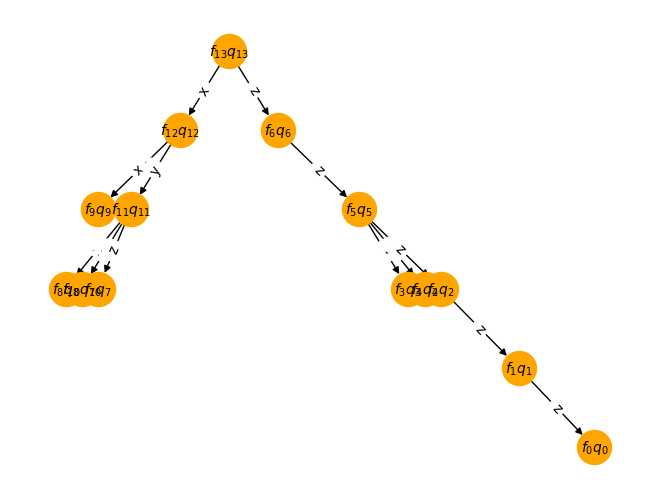

In [4]:
fast_hatt_tree = fast_hatt(fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--"))), n_modes=ones.shape[0], coeff_weight=False)
draw_tt(fast_hatt_tree, enumeration_scheme=fast_hatt_tree.default_enumeration_scheme())

# POC: Jordan-Wigner

For JW we enforce that we start with the node farthest from the root, then each subsequent node is attached as the Z-parent of the previous.

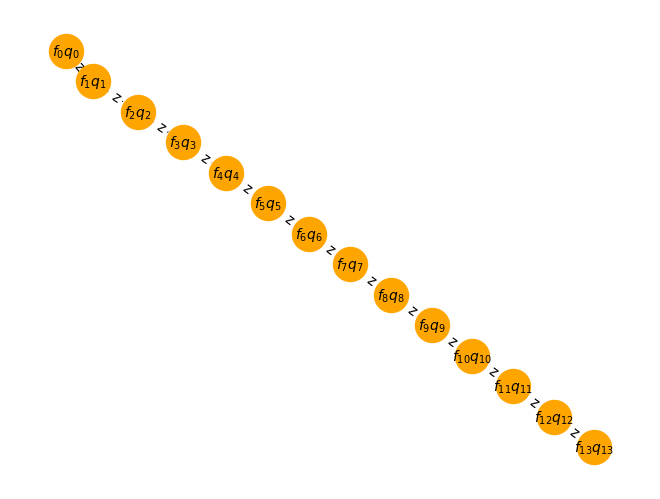

In [5]:
from ferrmion.encode import JordanWigner
from ferrmion.visualise import draw_tt
base_jw = JordanWigner(14)
draw_tt(base_jw, enumeration_scheme=base_jw.default_enumeration_scheme())

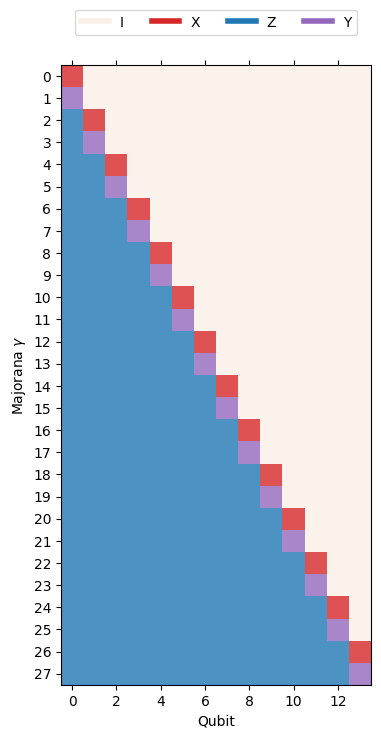

In [6]:
symplectic_matshow(JordanWigner(14)._build_symplectic_matrix()[1])

In [7]:
def jw_hatt(
    majorana_ham: dict[Iterable[int], float], n_modes: int, coeff_weight:bool=False,
) -> TernaryTree:
    """Construct an adaptive ternary tree from a majorana Hamiltonian.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Majorana Hamiltonian to encode.
        n_modes (int): Number of fermionic modes in the system.

    Returns:
        TTNode: Root node of the constructed ternary tree.
    """
    # if coeff_weight:
        # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0])*item[1], reverse=True)}
    # else:
        # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0]), reverse=True)}

    n_leaves = 2*n_modes +1
    # We need 2*M +1 leaves and M nodes.
    nodes: dict[int, TTNode | None] = {i: None for i in range(n_leaves)}
    for i in range(n_modes):
        nodes[n_leaves+ i] = TTNode(qubit_label=i)

    # Start with all the leaves unassigned
    unassigned = [*range(n_leaves)]
    unassigned.reverse()

    # We create two maps, of z_ancestors and z_descendants
    ancestor_map = {i: i for i in range(n_leaves + n_modes)}
    descendant_map = {i: i for i in range(n_leaves  + n_modes)}

    total_weight = 0
    for i in range(n_modes+1):
        print(f"{len(unassigned)=}, {unassigned=}")
        parent_index = n_leaves + i
        parent = nodes[parent_index]

        min_weight = np.inf
        selection = [None, None, None]
        # reverse because best is usually at the end 
        # reversed_combinations = [c for c in combinations(unassigned, 2)]

        # Z-child of new node will always be the previous node.
        # We only need to use every second entry in unassigned
        # as we already order odd/even terms
        # we also know for jw that every new node will be
        # the z-ancestor all all other nodes.
        z_index = unassigned[0]
        for x_index in unassigned[1::2]:
            small_y = None
            small_x = None
            # Now that we are enforcing a topology
            # we actually need to set the combination
            comb = z_index, x_index

            small_x = descendant_map[x_index]

            # discard this combination
            if small_x == 2 * n_modes:
                continue

            if small_x % 2 == 0:
                small_y = small_x + 1
            else:
                small_y = small_x - 1
            # We can't use this index for y a
            # it has been used in the combination already
            # so we'd be replacing our x or z!
            if small_y in comb:
                # print("small_y in comb")
                continue

            y_index = ancestor_map[small_y]

            if y_index in comb:
                # print("y index in comb")
                continue

            if small_x % 2 == 0:
                comb = [x_index, y_index, z_index]
            else:
                comb = [y_index, x_index, z_index]
            # comb = [int(i) for i in comb]

            # W3 can end uop with the same combination in two different ways
            if comb == selection:
                continue
            # tc = tuple(comb)
            # if tc in checked:
            #     continue
            # checked.add(tc)

            weight = 0
            if coeff_weight:
                for key, val in majorana_ham.items():
                    if min(comb) > max(key):
                        continue
                    elif max(comb) < min(key):
                        continue
                    else:
                        odd_parity_paulis = [sum([t!=c for t in key])%2 for c in comb]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        weight *= abs(val)
                    if weight > min_weight:
                        break
            else:
                for key in majorana_ham.keys():
                    if min(comb) > max(key):
                        continue
                    elif max(comb) < min(key):
                        continue
                    else:
                        odd_parity_paulis = [sum([t!=c for t in key])%2 for c in comb]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        if weight > min_weight:
                            break
                # ) 
            if weight < min_weight:
                # print(f"NEW Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                min_weight = weight
                selection = comb
            # elif weight == min_weight:
            # #     # print(f"SAME Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
            #     min_weight = weight
            #     selection = comb
            # would be better to break on zero
            # if weight == 0:
            #     break

        total_weight += min_weight
        # print(f"{selection=}")
        # Now find the Y pair of the x-node
        unassigned = [ u for u in unassigned if u not in selection]
        for child_index, char in zip(selection, ["x", "y", "z"]):
            if isinstance(nodes.get(child_index, None), TTNode):
                # print(f"{child_index} {nodes[child_index]}")
                # print(f"Child node {char=} with index {child_index=} is node {nodes.get(child_index).qubit_label=}")
                parent.add_child(which_child=char, child_node=nodes.get(child_index))
            else:
                parent.leaf_majorana_indices[char] = child_index

        # unassigned.append(parent_index)
        unassigned = [parent_index] + unassigned
        
        if i +1 == n_modes:
            break

        z_index = selection[2]
        z_desc = descendant_map[z_index]
        descendant_map[parent_index] = z_desc
        ancestor_map[z_index] = parent_index
        ancestor_map[z_desc] = parent_index

        # print("START reducing hamiltonian")
        majorana_ham = _reduce_hamiltonian(majorana_ham, parent_index, selection)
        # print("STOP reducing hamiltonian")

    if len(unassigned) != 1:
        raise ValueError(f"Not all nodes assigned by HATT. {unassigned=}")

    last_node = nodes[unassigned[0]]
    if isinstance(last_node, TTNode):
        root = last_node
    else:
        raise ValueError("Hatt root node is not a TTNode object.")

    tree = TernaryTree(n_modes=n_modes, root_node=root)
    tree.enumeration_scheme = tree.default_enumeration_scheme()
    tree.pauli_weight = total_weight
    print(total_weight)
    return tree

In [8]:
from ferrmion.utils import fermionic_to_sparse_majorana
jw_hatt_tree = jw_hatt(fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--"))), n_modes=ones.shape[0], coeff_weight=False)

len(unassigned)=29, unassigned=[28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=27, unassigned=[29, 27, 26, 25, 24, 23, 22, 21, 20, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=25, unassigned=[30, 27, 26, 25, 24, 23, 22, 21, 20, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=23, unassigned=[31, 25, 24, 23, 22, 21, 20, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=21, unassigned=[32, 25, 24, 23, 22, 21, 20, 15, 14, 13, 12, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=19, unassigned=[33, 23, 22, 21, 20, 15, 14, 13, 12, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=17, unassigned=[34, 23, 22, 21, 20, 15, 14, 13, 12, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=15, unassigned=[35, 23, 22, 21, 20, 15, 14, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=13, unassigned=[36, 23, 22, 21, 20, 15, 14, 7, 6, 3, 2, 1, 0]
len(unassigned)=11, unassigned=[37, 23

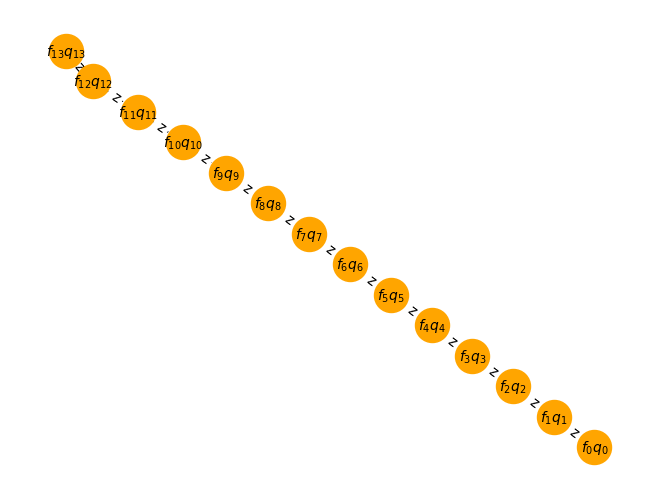

In [9]:
draw_tt(jw_hatt_tree, enumeration_scheme=jw_hatt_tree.default_enumeration_scheme())

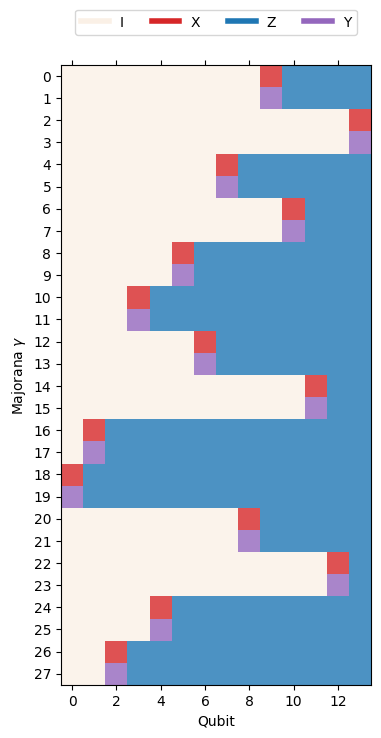

In [10]:
from ferrmion.visualise import symplectic_matshow
symplectic_matshow(jw_hatt_tree._build_symplectic_matrix()[1])

In [11]:
def pauli_weights(pauli_hamiltonian: dict[str, float]) -> list[float]:
    unscaled_terms = []
    scaled_terms = []
    for k, v in pauli_hamiltonian.items():
        assert v != 0
        pw = (len(k) - k.count("I")) 
        unscaled_terms.append(pw)
        scaled_terms.append(pw* np.abs(v))

    return (unscaled_terms, scaled_terms, len(pauli_hamiltonian))

In [12]:
from ferrmion.hamiltonians import fill_template, molecular_hamiltonian_template
def fill_template_find_norms(template, ones, twos, permutation):
    permutation = np.array(permutation, dtype=np.uint)
    ham = fill_template(template, 0, ones, twos, permutation)
    
    return pauli_weights(ham)

# JW TOPPHATT 

In [13]:
from ferrmion.utils import fermionic_to_sparse_majorana
jw_hatt_tree = jw_hatt(fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--"))), n_modes=ones.shape[0], coeff_weight=False)
template = molecular_hamiltonian_template(*jw_hatt_tree._build_symplectic_matrix(), physicist_notation=True)
result = fill_template_find_norms(template, ones, twos, [*range(14)])
sdmeans_topphatt = {}
sdmeans_topphatt["unscaled"] = np.mean(result[0])
sdmeans_topphatt["scaled"] = np.mean(result[1])
sdmeans_topphatt["length"] = result[2]

len(unassigned)=29, unassigned=[28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=27, unassigned=[29, 27, 26, 25, 24, 23, 22, 21, 20, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=25, unassigned=[30, 27, 26, 25, 24, 23, 22, 21, 20, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=23, unassigned=[31, 25, 24, 23, 22, 21, 20, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=21, unassigned=[32, 25, 24, 23, 22, 21, 20, 15, 14, 13, 12, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=19, unassigned=[33, 23, 22, 21, 20, 15, 14, 13, 12, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=17, unassigned=[34, 23, 22, 21, 20, 15, 14, 13, 12, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=15, unassigned=[35, 23, 22, 21, 20, 15, 14, 7, 6, 5, 4, 3, 2, 1, 0]
len(unassigned)=13, unassigned=[36, 23, 22, 21, 20, 15, 14, 7, 6, 3, 2, 1, 0]
len(unassigned)=11, unassigned=[37, 23

# JW Naive

In [14]:
sdmeans_naive = {}
rng = np.random.RandomState(1017)

sym = JordanWigner(ones.shape[0])._build_symplectic_matrix()
template = molecular_hamiltonian_template(*sym, physicist_notation=True)

result = fill_template_find_norms(template, ones, twos, np.array([*range(ones.shape[0])], dtype=np.uint))
sdmeans_naive["unscaled"] = np.mean(result[0])
sdmeans_naive["scaled"] = np.mean(result[1])
sdmeans_naive["length"] = result[2]
sdmeans_naive

{'unscaled': np.float64(7.057090239410681),
 'scaled': np.float64(0.17624542204398874),
 'length': 1086}

# JW Annealed

In [15]:
from ferrmion.core import anneal_enumerations    
import numpy as np
sdmeans_annealed = {}
annealed_best = anneal_enumerations(template, ones, twos, temperature=ones.shape[0], initial_guess=np.array([*range(ones.shape[0])],dtype=np.uint), coefficient_weighted=False)
result = fill_template_find_norms(template, ones, twos, annealed_best[1])
sdmeans_annealed["unscaled"] = np.mean(result[0])
sdmeans_annealed["scaled"] = np.mean(result[1])
sdmeans_annealed["length"] = result[2]
sdmeans_annealed

{'unscaled': np.float64(4.976058931860037),
 'scaled': np.float64(0.12739479627750752),
 'length': 1086}

# JW Random Permutations

In [16]:
limit = 100
sdmeans = {}
sdmeans = {"unscaled":[], "scaled":[], "length":[]}
i=0
while i < limit:
    perm = rng.permutation(ones.shape[0])
    result = fill_template_find_norms(template, ones, twos, perm)
    sdmeans["unscaled"].append(np.mean(result[0])) 
    sdmeans["scaled"].append(np.mean(result[1]))
    sdmeans["length"].append(result[2])
    i+=1
sdmeans.keys()

dict_keys(['unscaled', 'scaled', 'length'])

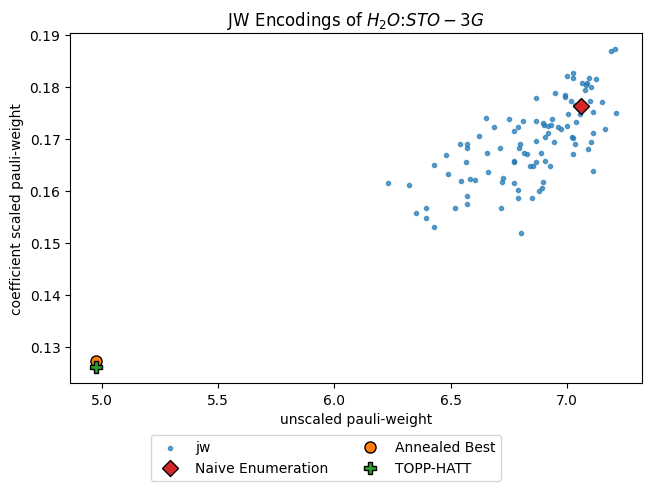

In [17]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

color_set = {"jw":"tab:blue", "pe":"tab:orange", "bk":"tab:green", "jkmn":"tab:red", "bonsai":"tab:purple", "huffman":"tab:brown", "hatt":"tab:pink"}
fig, ax = plt.subplots(layout="constrained")

for encoding in ["jw"]:
    color = color_set[encoding]
    # ax.scatter([],[], label=encoding, marker=".", color=color, alpha=0.7)
    ax.scatter(sdmeans["unscaled"], sdmeans["scaled"], label=encoding, marker=".", color=color_set[encoding], alpha=0.7)
    ax.plot(sdmeans_naive["unscaled"], sdmeans_naive["scaled"], marker="D", color="tab:red", mec="k", markersize=8)
    ax.plot(sdmeans_annealed["unscaled"], sdmeans_annealed["scaled"], marker="o", color="tab:orange", mec="k", markersize=8)
    ax.plot(sdmeans_topphatt["unscaled"], sdmeans_topphatt["scaled"], marker="P", color="tab:green", mec="k", markersize=8)


#Imports

# where some data has already been plotted to ax
handles, labels = plt.gca().get_legend_handles_labels()

# manually define a new patch 
naive_legend = mlines.Line2D([], [], label='Naive Enumeration', marker="D", linestyle="", color="tab:red", mec="k", markersize=8)
annealed_legend = mlines.Line2D([], [], label='Annealed Best', marker="o", linestyle="",color="tab:orange", mec="k", markersize=8)
topphatt_legend = mlines.Line2D([], [], label='TOPP-HATT', marker="P", linestyle="",color="tab:green", mec="k", markersize=8)

# handles is a list, so append manual patch
handles.extend([naive_legend, annealed_legend, topphatt_legend])

ax.set_xlabel("unscaled pauli-weight")
ax.set_ylabel("coefficient scaled pauli-weight")
ax.set_title("JW Encodings of $H_2 O$:$STO-3G$")
fig.legend(handles=handles, loc="outside lower center", ncols=len(handles)//2)

# TOPP-HATT

In [18]:
from ferrmion.encode import TernaryTree
def topp_hatt(
    majorana_ham: dict[Iterable[int], float],
    tree: TernaryTree,
    coeff_weight:bool=False,
) -> TernaryTree:
    """Construct an adaptive ternary tree from a majorana Hamiltonian.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Majorana Hamiltonian to encode.
        n_modes (int): Number of fermionic modes in the system.

    Returns:
        TTNode: Root node of the constructed ternary tree.
    """
    # if coeff_weight:
        # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0])*item[1], reverse=True)}
    # else:
        # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0]), reverse=True)}
    n_modes = tree.n_modes
    n_leaves = 2*n_modes +1
    # We need 2*M +1 leaves and M nodes.
    nodes: dict[int, TTNode | None] = {i: None for i in range(n_leaves)}
    for i in range(n_modes):
        nodes[n_leaves+ i] = TTNode(qubit_label=i)

    # Start with all the leaves unassigned
    unassigned = [*range(n_leaves)]
    unassigned.reverse()

    # We create two maps, of z_ancestors and z_descendants
    ancestor_map = {i: i for i in range(n_leaves + n_modes)}
    descendant_map = {i: i for i in range(n_leaves  + n_modes)}

    total_weight = 0
    for i in range(n_modes+1):
        print(f"{len(unassigned)=}, {unassigned=}")
        parent_index = n_leaves + i
        parent = nodes[parent_index]

        min_weight = np.inf
        selection = [None, None, None]
        # reverse because best is usually at the end 
        # reversed_combinations = [c for c in combinations(unassigned, 2)]

        # Z-child of new node will always be the previous node.
        # We only need to use every second entry in unassigned
        # as we already order odd/even terms
        # we also know for jw that every new node will be
        # the z-ancestor all all other nodes.

        z_index = unassigned[0]
        for x_index in unassigned[1::2]:
            small_y = None
            small_x = None
            # Now that we are enforcing a topology
            # we actually need to set the combination
            comb = z_index, x_index

            small_x = descendant_map[x_index]

            # discard this combination
            if small_x == 2 * n_modes:
                continue

            if small_x % 2 == 0:
                small_y = small_x + 1
            else:
                small_y = small_x - 1
            # We can't use this index for y a
            # it has been used in the combination already
            # so we'd be replacing our x or z!
            if small_y in comb:
                # print("small_y in comb")
                continue

            y_index = ancestor_map[small_y]

            if y_index in comb:
                # print("y index in comb")
                continue

            if small_x % 2 == 0:
                comb = [x_index, y_index, z_index]
            else:
                comb = [y_index, x_index, z_index]
            # comb = [int(i) for i in comb]

            # W3 can end uop with the same combination in two different ways
            if comb == selection:
                continue
            # tc = tuple(comb)
            # if tc in checked:
            #     continue
            # checked.add(tc)

            weight = 0
            if coeff_weight:
                for key, val in majorana_ham.items():
                    if min(comb) > max(key):
                        continue
                    elif max(comb) < min(key):
                        continue
                    else:
                        odd_parity_paulis = [sum([t!=c for t in key])%2 for c in comb]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        weight *= abs(val)
                    if weight > min_weight:
                        break
            else:
                for key in majorana_ham.keys():
                    if min(comb) > max(key):
                        continue
                    elif max(comb) < min(key):
                        continue
                    else:
                        odd_parity_paulis = [sum([t!=c for t in key])%2 for c in comb]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        if weight > min_weight:
                            break
                # ) 
            if weight < min_weight:
                # print(f"NEW Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                min_weight = weight
                selection = comb
            # elif weight == min_weight:
            # #     # print(f"SAME Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
            #     min_weight = weight
            #     selection = comb
            # would be better to break on zero
            # if weight == 0:
            #     break

        total_weight += min_weight
        # print(f"{selection=}")
        # Now find the Y pair of the x-node
        unassigned = [ u for u in unassigned if u not in selection]
        for child_index, char in zip(selection, ["x", "y", "z"]):
            if isinstance(nodes.get(child_index, None), TTNode):
                # print(f"{child_index} {nodes[child_index]}")
                # print(f"Child node {char=} with index {child_index=} is node {nodes.get(child_index).qubit_label=}")
                parent.add_child(which_child=char, child_node=nodes.get(child_index))
            else:
                parent.leaf_majorana_indices[char] = child_index

        # unassigned.append(parent_index)
        unassigned = [parent_index] + unassigned
        
        if i +1 == n_modes:
            break

        z_index = selection[2]
        z_desc = descendant_map[z_index]
        descendant_map[parent_index] = z_desc
        ancestor_map[z_index] = parent_index
        ancestor_map[z_desc] = parent_index

        # print("START reducing hamiltonian")
        majorana_ham = _reduce_hamiltonian(majorana_ham, parent_index, selection)
        # print("STOP reducing hamiltonian")

    if len(unassigned) != 1:
        raise ValueError(f"Not all nodes assigned by HATT. {unassigned=}")

    last_node = nodes[unassigned[0]]
    if isinstance(last_node, TTNode):
        root = last_node
    else:
        raise ValueError("Hatt root node is not a TTNode object.")

    tree = TernaryTree(n_modes=n_modes, root_node=root)
    tree.enumeration_scheme = tree.default_enumeration_scheme()
    tree.pauli_weight = total_weight
    print(total_weight)
    return tree

# Plan

- Restrict the iterator in each loop to a product of allowed values for x,y,z


# Implementation steps
-[x] Product of allowed iterations, where allowed is simply unassigned

### Baseline FastHATT

In [19]:
def fast_hatt(
    majorana_ham: dict[Iterable[int], float],
    n_modes: int,
    coeff_weight: bool = False,
) -> TernaryTree:
    """Construct an adaptive ternary tree from a majorana Hamiltonian.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Majorana Hamiltonian to encode.
        n_modes (int): Number of fermionic modes in the system.
        coeff_weight (bool): Multiply Pauli-weight by coefficient norm.

    Returns:
        TTNode: Root node of the constructed ternary tree.
    """
    # if coeff_weight:
    # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0])*item[1], reverse=True)}
    # else:
    # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0]), reverse=True)}

    n_leaves = 2 * n_modes + 1
    # We need 2*M +1 leaves and M nodes.
    nodes: dict[int, TTNode | None] = {i: None for i in range(n_leaves)}
    for i in range(n_modes):
        nodes[n_leaves + i] = TTNode(qubit_label=i)

    # Start with all the leaves unassigned
    unassigned = [*range(n_leaves)]
    unassigned.reverse()

    # We create two maps, of z_ancestors and z_descendants
    ancestor_map = {i: i for i in range(n_leaves + n_modes)}
    descendant_map = {i: i for i in range(n_leaves + n_modes)}

    total_weight = 0
    for i in range(n_modes + 1):
        parent_index = n_leaves + i
        parent = nodes[parent_index]

        min_weight = np.inf
        selection = [None, None, None]
        previous = [None, None, None]
        # reverse because best is usually at the end
        # reversed_combinations = [c for c in combinations(unassigned, 2)]
        if i == 0:
            comb_iterator = ([n_leaves - 1, i] for i in range(n_leaves - 1)[::-1])
        else:
            comb_iterator = permutations(unassigned, 2)

        for comb in comb_iterator:
            # print(f"{comb=}")
            small_y = None
            small_x = None
            # This way x index will be higher term - more often node.
            z_index, x_index = comb
            # x_index, z_index = comb

            small_x = descendant_map[x_index]

            # discard this combination
            if small_x == 2 * n_modes:
                # print("small x is all z")
                continue

            if small_x % 2 == 0:
                small_y = small_x + 1
            else:
                small_y = small_x - 1
            # We can't use this index for y a
            # it has been used in the combination already
            # so we'd be replacing our x or z!
            if small_y in comb:
                # print("small_y in comb")
                continue

            y_index = ancestor_map[small_y]

            if y_index in comb:
                # print("y index in comb")
                continue

            if small_x % 2 == 0:
                comb = [x_index, y_index, z_index]
            else:
                comb = [y_index, x_index, z_index]
            # comb = [int(i) for i in comb]

            # W3 can end uop with the same combination in two different ways
            if comb == selection:
                continue
            if comb == previous:
                continue
            previous = comb
            # tc = tuple(comb)
            # if tc in checked:
            #     continue
            # checked.add(tc)

            weight = 0
            if coeff_weight:
                for key, val in majorana_ham.items():
                    if min(comb) > key[-1]:
                        continue
                    elif max(comb) < key[0]:
                        continue
                    else:
                        odd_parity_paulis = [
                            sum([t != c for t in key]) % 2 for c in comb
                        ]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        weight *= abs(val)
                    if weight > min_weight:
                        break
            else:
                for key in majorana_ham.keys():
                    if min(comb) > key[-1]:
                        continue
                    elif max(comb) < key[0]:
                        continue
                    else:
                        odd_parity_paulis = [
                            sum([t != c for t in key]) % 2 for c in comb
                        ]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        if weight > min_weight:
                            break
                # weight = np.sum(
                #     [_qubit_term_weight(term, comb) for term in majorana_ham.keys()]
                # )
            if weight < min_weight:
                # print(f"NEW Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                min_weight = weight
                selection = comb
            # elif weight == min_weight:
                #     # print(f"SAME Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                # min_weight = weight
                # selection = comb
            # would be better to break on zero
            # if weight == 0:
            #     break

        total_weight += min_weight
        print(f"{selection=}")
        # Now find the Y pair of the x-node
        unassigned = [u for u in unassigned if u not in selection]
        for child_index, char in zip(selection, ["x", "y", "z"]):
            if isinstance(nodes.get(child_index, None), TTNode):
                # print(f"{child_index} {nodes[child_index]}")
                # print(f"Child node {char=} with index {child_index=} is node {nodes.get(child_index).qubit_label=}")
                parent.add_child(which_child=char, child_node=nodes.get(child_index))
            else:
                parent.leaf_majorana_indices[char] = child_index

        # unassigned.append(parent_index)
        unassigned = [parent_index] + unassigned

        if i + 1 == n_modes:
            break

        z_index = selection[2]
        z_desc = descendant_map[z_index]
        descendant_map[parent_index] = z_desc
        ancestor_map[z_index] = parent_index
        ancestor_map[z_desc] = parent_index

        # print("START reducing hamiltonian")
        majorana_ham = _reduce_hamiltonian(majorana_ham, parent_index, selection)
        # print("STOP reducing hamiltonian")

    if len(unassigned) != 1:
        raise ValueError(f"Not all nodes assigned by HATT. {unassigned=}")

    last_node = nodes[unassigned[0]]
    if isinstance(last_node, TTNode):
        root = last_node
    else:
        raise ValueError("Hatt root node is not a TTNode object.")

    tree = TernaryTree(n_modes=n_modes, root_node=root)
    tree.enumeration_scheme = tree.default_enumeration_scheme()
    tree.pauli_weight = total_weight
    print("Total Weight: ", total_weight)
    return tree

In [20]:
fast_hatt(fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--"))), n_modes=14, coeff_weight=False)

selection=[18, 19, 28]
selection=[16, 17, 29]
selection=[26, 27, 30]
selection=[8, 9, 25]
selection=[10, 11, 24]
selection=[33, 32, 31]
selection=[12, 13, 34]
selection=[6, 7, 15]
selection=[4, 5, 14]
selection=[2, 3, 22]
selection=[38, 23, 36]
selection=[0, 1, 35]
selection=[20, 21, 40]
selection=[37, 39, 41]
Total Weight:  2551


# Defining Restrictions

All Z-node
- Z-majorana must be 2n

Terminal nodes
- no restrictions, x,y,z majoranas can be any number.

Z-Parents
- Z-child must be retained

X-Parents
- X-child must be retained
- x-majorana of parent is z-leaf of X-child's z-decendant

Y-Parents
- Y-child must be retained
- y-majorana of parent is z-leaf of Y-child's z-decendant



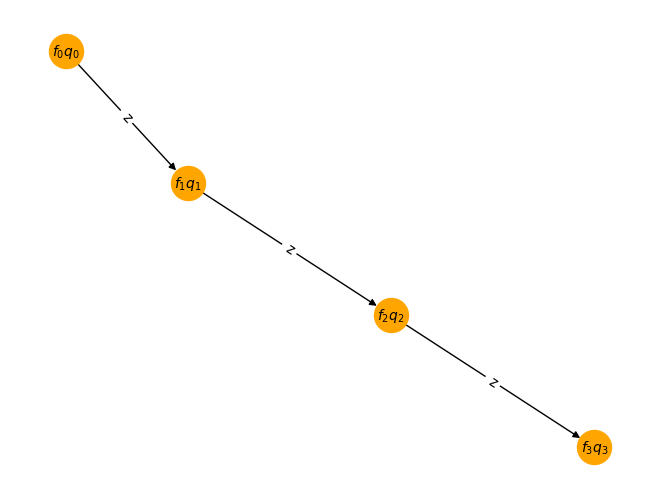

In [21]:
tree = JordanWigner(4)
draw_tt(tree, enumeration_scheme=tree.default_enumeration_scheme())

## Initialise the restrictions

We should be able to set all of these exactly, as we know the structure of the tree ahead of time.

In [22]:
from ferrmion.encode.ternary_tree_node import TTNode
def get_node(root_node: TTNode, child_string: str):
    node = root_node
    for char in child_string:
        node = getattr(node, char)
    return node

def add_all_z_restriction(tree,string_index_map, restrictions):
    child_strings = tree.root_node.child_strings
    all_z = sorted({child for child in child_strings if "x" not in child and "y" not in child}, key=len, reverse=True)[0]
    all_z_index = string_index_map[all_z]
    restrictions[all_z_index][2] = [2*tree.n_modes]
    return restrictions

def majorana_indices_of_node(node_index, n_leaves) -> int:
    x_majorana = 2*(node_index - n_leaves)
    y_majorana = x_majorana+1
    return x_majorana, y_majorana

def get_twinned_majorana_index(node: TTNode):
    index = node.leaf_majorana_indices["z"]
    if index is None:
        return None
    if index %2 == 0:
        return index + 1
    else:
        return index - 1


def add_retain_child_restrictions(tree:TernaryTree, string_index_map, restrictions):
    """Nodes that have a child."""
    child_strings = tree.root_node.child_strings
    for node in child_strings:
        if node == "":
            continue
        parent = node[:-1]
        parent_index = string_index_map[parent]
        node_index = string_index_map[node]
        match node[-1]:
            case "x":
                restrictions[parent_index][0] = [node_index]
            case "y":
                restrictions[parent_index][1] = [node_index]
            case "z":
                restrictions[parent_index][2] = [node_index]
    return restrictions

def add_xy_parent_restrictions(
        tree:TernaryTree, 
        string_index_map:dict[str,int], 
        node_objects_map:dict[int, TTNode],
        restrictions:dict[int, list[int|None]]
        ):
    """Nodes that have an X-parent or Y-parent."""
    child_strings = tree.root_node.child_strings
    parent_strings = {child[:-1] for child in child_strings}
    n_leaves = 2*tree.n_modes
    for child in child_strings:
        child_index = string_index_map[child]
        child_node = node_objects_map[child_index]
        #child can be it's own ancestor
        ancestor= child_node.z_ancestor

        if ancestor.root_path == "":
            continue
        # Z-ancestors of an x-child have even z-leaf
        if ancestor.root_path[-1] == "x":
            restrictions[child_index][2] = [*range(0,n_leaves,2)]
        # Z-ancestors of an y-child have odd z-leaf
        elif ancestor.root_path[-1]=="y":
            restrictions[child_index][2] = [*range(1,n_leaves,2)]

    return restrictions

def get_string_index_map(tree):
    n_leaves = 2*tree.n_modes+1
    enumeration_scheme = tree.default_enumeration_scheme()
    child_strings = tree.root_node.child_strings
    return {child: n_leaves+enumeration_scheme[child][1] for child in child_strings}

def get_node_objects_map(tree, string_index_map):
    return {string_index_map[child]: get_node(tree.root_node, child) for child in tree.root_node.child_strings}

def initialise_restrictions(tree:TernaryTree):
    string_index_map = get_string_index_map(tree)
    node_objects_map = get_node_objects_map(tree, string_index_map)
    # each node has restrictions in tuple (restrictions on x, restrictions on y, restrictions on z)
    restrictions = {i: [None, None, None] for i in string_index_map.values()}
    restrictions = add_xy_parent_restrictions(tree, string_index_map, node_objects_map, restrictions)
    restrictions = add_retain_child_restrictions(tree, string_index_map, restrictions)
    restrictions = add_all_z_restriction(tree,string_index_map, restrictions)
    return restrictions

In [23]:
from ferrmion.encode import BK, ParityEncoding, JordanWigner
def initialise_node_dependencies(tree:TernaryTree):
    string_index_map = get_string_index_map(tree)
    child_strings = tree.root_node.child_strings
    dependencies = {string_index_map[child]:[] for child in child_strings}

    for child in child_strings:
        for char in ["x","y","z"]:
            if child+char in child_strings:
                dependencies[string_index_map[child]].append(string_index_map[child+char])
    return dependencies

initialise_node_dependencies(BK(4))

{9: [10], 10: [11, 12], 11: [], 12: []}

In [24]:
jwr = initialise_restrictions(JordanWigner(4))
jwr

{9: [None, None, [10]],
 10: [None, None, [11]],
 11: [None, None, [12]],
 12: [None, None, [8]]}

In [25]:
initialise_restrictions(ParityEncoding(4))


{9: [[10], None, [8]],
 10: [[11], None, [0, 2, 4, 6]],
 11: [[12], None, [0, 2, 4, 6]],
 12: [None, None, [0, 2, 4, 6]]}

In [32]:
from ferrmion.encode import TernaryTree
from types import LambdaType
from itertools import product
from typing import Callable

def build_valid_combination(comb: tuple[int,int], 
                      descendant_map:dict, 
                      ancestor_map:dict, 
                      n_modes:int, 
                      selection:list[int,int,int], 
                      ) -> None|list[int,int,int]:
    # print(f"{comb=}")
    z_index, x_index = comb
    if z_index == x_index:
        return None

    small_y = None
    small_x = None

    small_x = descendant_map[x_index]

    # discard this combination
    if small_x == 2 * n_modes:
        return None

    if small_x % 2 == 0:
        small_y = small_x + 1
    else:
        small_y = small_x - 1
    # We can't use this index for y a
    # it has been used in the combination already
    # so we'd be replacing our x or z!
    if small_y in comb:
        return None

    y_index = ancestor_map[small_y]

    if y_index in comb:
        return None

    if small_x % 2 == 0:
        comb = [x_index, y_index, z_index]
    else:
        comb = [y_index, x_index, z_index]

    # W3 can end uop with the same combination in two different ways
    if comb == selection:
        return None
    return comb

def unpack_single_restriction(restriction: None|list[int]|Callable, unassigned_leaves:set):
    if restriction is None:
        restriction = unassigned_leaves
    # a REQUIRED assignment will be removed from unassigned_leaves
    elif isinstance(restriction, list) and len(restriction)==1:
        restriction = restriction
    elif isinstance(restriction, list):
        restriction = [r for r in restriction if r in unassigned_leaves]
    else:
        raise ValueError("Restriction should be None or list.")
    return restriction

def topp_hatt(
    majorana_ham: dict[Iterable[int], float],
    tree: TernaryTree,
    coeff_weight:bool=False,
) -> TernaryTree:
    """Construct an adaptive ternary tree from a majorana Hamiltonian.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Majorana Hamiltonian to encode.
        n_modes (int): Number of fermionic modes in the system.

    Returns:
        TTNode: Root node of the constructed ternary tree.
    """
    # if coeff_weight:
        # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0])*item[1], reverse=True)}
    # else:
        # majorana_ham = {k:v for k,v in sorted(majorana_ham.items(), key=lambda item: sum(item[0]), reverse=True)}
    n_modes = tree.n_modes
    n_leaves = 2*n_modes +1
    # We need 2*M +1 leaves and M nodes.
    nodes: dict[int, TTNode | None] = {i: None for i in range(n_leaves-1)}
    node_dependencies = initialise_node_dependencies(tree)
    print(f"Initial Dependencies:\n{node_dependencies}")

    string_index_map = get_string_index_map(tree)
    node_objects_map = get_node_objects_map(tree, string_index_map)
    
    for node in node_objects_map.values():
        for char in ["x","y","z"]:
            node.branch_majorana_map[char] = None

    nodes.update(get_node_objects_map(tree, string_index_map))
    
    active_nodes:set[int] = {node for node, deps in node_dependencies.items() if deps == []}
    completed_nodes = set()
    restrictions = initialise_restrictions(tree)
    print(f"Initial Restrictions:\n{restrictions}")
    # Start with all the leaves unassigned
    unassigned_leaves = [*range(n_leaves)]
    unassigned_leaves.reverse()

    # We create two maps, of z_ancestors and z_descendants
    ancestor_map = {i: i for i in range(n_leaves + n_modes)}
    descendant_map = {i: i for i in range(n_leaves  + n_modes)}

    total_weight = 0
    for i in range(n_modes+1):
        print(f"\nLoop {i}")
        # Update the restrictions with the new information about the tree.
        # Any nodes that are required to be in a certain position 
        # have to be removed from unassigned!
        to_remove = []
        for restriction in restrictions.values():
            for term in restriction:
                if isinstance(term, list) and len(term)==1:
                    to_remove.append(term[0])
        unassigned_leaves = [l for l in unassigned_leaves if l not in to_remove]

        min_weight = np.inf
        min_parent = None
        selection = [None, None, None]
        
        # NOTE
        # Another opion would be to check all allowed
        # combinations just once and then to look 
        # for the parent that is eligable for the minimum combination.
        print(f"{active_nodes=}")
        for parent_index in active_nodes:
            print(f"\n{parent_index=}")


            # Z-child of new node will always be the previous node.
            # We only need to use every second entry in unassigned
            # as we already order odd/even terms
            # we also know for jw that every new node will be
            # the z-ancestor all all other nodes.

            parent_restrictions = restrictions[parent_index]

            allowed_x = unpack_single_restriction(parent_restrictions[0], unassigned_leaves)
            allowed_y = unpack_single_restriction(parent_restrictions[1], unassigned_leaves)
            allowed_z = unpack_single_restriction(parent_restrictions[2], unassigned_leaves)

            match parent_restrictions[0], parent_restrictions[1]:
                case None, None:
                    allowed_product = product(allowed_z, allowed_x)
                case list(), None:
                    allowed_product = product(allowed_z, allowed_x)
                case None, list():
                    allowed_product = product(allowed_z, allowed_y)
                case list(), list():
                    allowed_product = product(allowed_x, allowed_y, allowed_z)

            # If x and y are both none, just do all x and create a pair
            # if x is none and y is set, just use y
            # if x is set and y is none, just use x

            print(f"{parent_restrictions=}")
            for comb in allowed_product:
                match len(comb):
                    case 2:
                        comb = build_valid_combination(comb, descendant_map, ancestor_map, n_modes, selection)
                        if comb is None:
                            continue
                    case 3:
                        # We can use the combination provided
                        comb = list(comb)
                    case _:
                        raise ValueError("Length of combination should be 2 or 3.")

                weight = 0
                for key in majorana_ham.keys():
                    if min(comb) > max(key):
                        continue
                    elif max(comb) < min(key):
                        continue
                    else:
                        odd_parity_paulis = [sum([t!=c for t in key])%2 for c in comb]
                        non_commuting = sum(odd_parity_paulis) % 3
                        weight += int(non_commuting != 0)
                        if weight > min_weight:
                            break

                if weight < min_weight:
                    # print(f"NEW Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                    min_weight = weight
                    selection = comb
                    min_parent = parent_index
                # elif weight == min_weight:
                # #     # print(f"SAME Min Node:{i}, Parent Index: {parent_index}, Comb: {comb}, Old Min:{min_weight }, New Min:{weight}")
                    # min_weight = weight
                    # selection = comb 
            print(f"{parent_index=}, {selection=}")
        total_weight += min_weight

        print(f"{min_parent=}")
        # Now find the Y pair of the x-node
        unassigned_leaves = [ u for u in unassigned_leaves if u not in selection]
        for child_index, char in zip(selection, ["x", "y", "z"]):
                node_objects_map[min_parent].leaf_majorana_indices[char] = child_index
        
        if i +1 == n_modes:
            break

        # print(f"Loop: {i}, Selection: {selection}, Chosen Parent: {min_parent},{index_string_map[min_parent]}")
        
        completed_nodes.add(min_parent)
        node_dependencies.pop(min_parent)
        active_nodes.remove(min_parent)
        for node,deps in node_dependencies.items():
            if completed_nodes.issuperset(deps):
                active_nodes.add(node)
        

        z_index = selection[2]

        # Update the restrictions on the parent node to be its selection.
        restrictions[min_parent] = selection
        # Use these to update restrictions on other nodes.

        parent_node = node_objects_map[min_parent]

        # The node may be its own z-ancestor
        restrictor = parent_node.z_ancestor
        print(f"{restrictor=}")

        print(f"{restrictions=}")
        if restrictor.root_path == "":
            pass
        elif restrictor.root_path[-1]=="x":
            if isinstance(restrictor.parent.y,TTNode):
                restricted = restrictor.parent.y.z_descendant
                print(f"{restricted=}")
                restrictions[string_index_map[restricted.root_path]][2] = [restrictor.z_descendant.leaf_majorana_indices["z"] +1]
            elif restrictor.parent.y is None:
                restricted = restrictor.parent
                print(f"{restricted=}")
                restrictions[string_index_map[restricted.root_path]][1] = [restrictor.z_descendant.leaf_majorana_indices["z"] +1]

                
        elif restrictor.root_path[-1]=="y":
            if isinstance(restrictor.parent.x,TTNode):
                restricted = restrictor.parent.x.z_descendant
                print(f"{restricted=}")
                restrictions[string_index_map[restricted.root_path]][2] = [restrictor.z_descendant.leaf_majorana_indices["z"] -1]
            elif restrictor.parent.x is None:
                restricted = restrictor.parent
                print(f"{restricted=}")
                restrictions[string_index_map[restricted.root_path]][0] = [restrictor.z_descendant.leaf_majorana_indices["z"] -1]
        print(f"{restrictions=}")
        z_desc = descendant_map[z_index]
        descendant_map[parent_index] = z_desc
        ancestor_map[z_index] = parent_index
        ancestor_map[z_desc] = parent_index

        majorana_ham = _reduce_hamiltonian(majorana_ham, parent_index, selection)

    if len(active_nodes) != 1:
        raise ValueError(f"Not all nodes assigned by HATT. {unassigned_leaves=}")

    last_node = nodes[active_nodes.pop()]
    if isinstance(last_node, TTNode):
        root = last_node
    else:
        raise ValueError("Hatt root node is not a TTNode object.")

    tree.pauli_weight = total_weight
    return tree

In [33]:
from ferrmion.optimize import hamiltonian_adaptive_ternary_tree
hatt_tree = hamiltonian_adaptive_ternary_tree(fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--"))), n_modes=14)

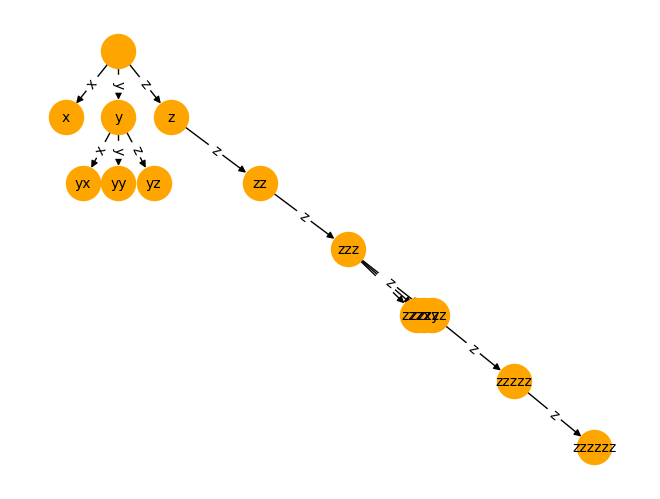

In [34]:
draw_tt(hatt_tree)

In [35]:
from ferrmion.optimize import huffman_ternary_tree
huffman_tree = huffman_ternary_tree(ones, twos)

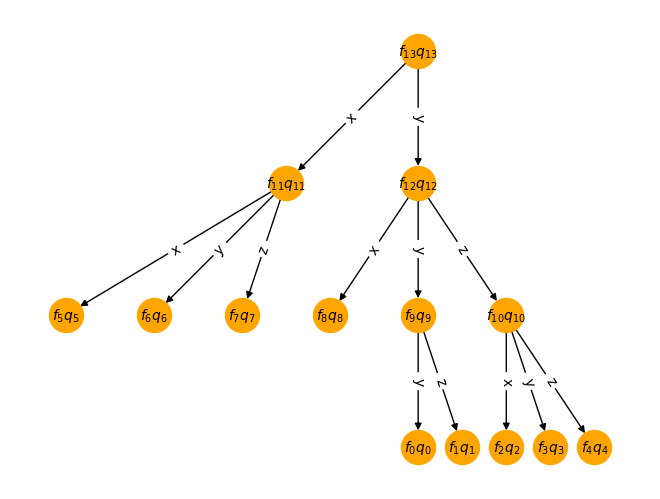

In [36]:
draw_tt(huffman_tree, enumeration_scheme=huffman_tree.default_enumeration_scheme())

In [37]:
topp_hatt(fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--"))), tree=huffman_tree, coeff_weight=False)


Initial Dependencies:
{42: [40, 41], 40: [34, 35, 36], 41: [37, 38, 39], 34: [], 35: [], 36: [], 37: [], 38: [29, 30], 39: [31, 32, 33], 29: [], 30: [], 31: [], 32: [], 33: []}
Initial Restrictions:
{42: [[40], [41], [28]], 40: [[34], [35], [36]], 41: [[37], [38], [39]], 34: [None, None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 35: [None, None, [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27]], 36: [None, None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 37: [None, None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 38: [None, [29], [30]], 39: [[31], [32], [33]], 29: [None, None, [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27]], 30: [None, None, [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27]], 31: [None, None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 32: [None, None, [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27]], 33: [None, None, None]}

Loop 0
active_nodes={32, 33, 34, 35, 36, 37, 29, 30, 31}

parent_index=32
parent_restri

In [39]:
from ferrmion.utils import fermionic_to_sparse_majorana
from ferrmion.core import anneal_enumerations    
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

def get_topp_hatt_results(tree: TernaryTree, name:str):
    print("Getting Naive result...")
    sdmeans_naive = {}
    rng = np.random.RandomState(1017)
    sym = tree._build_symplectic_matrix()
    template = molecular_hamiltonian_template(*sym, physicist_notation=True)
    result = fill_template_find_norms(template, ones, twos, np.array([*range(ones.shape[0])], dtype=np.uint))
    sdmeans_naive["unscaled"] = np.mean(result[0])
    sdmeans_naive["scaled"] = np.mean(result[1])
    sdmeans_naive["length"] = result[2]
    
    print("Getting Annealed result...")
    sdmeans_annealed = {}
    annealed_best = anneal_enumerations(template, ones, twos, temperature=ones.shape[0], initial_guess=np.array([*range(ones.shape[0])],dtype=np.uint), coefficient_weighted=False)
    result = fill_template_find_norms(template, ones, twos, annealed_best[1])
    sdmeans_annealed["unscaled"] = np.mean(result[0])
    sdmeans_annealed["scaled"] = np.mean(result[1])
    sdmeans_annealed["length"] = result[2]
    sdmeans_annealed

    print("Running TOPP-HATT...")
    hatt_tree = topp_hatt(fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--"))), tree=tree, coeff_weight=False)
    print("Getting TOPP-HATT result...")
    template = molecular_hamiltonian_template(*hatt_tree._build_symplectic_matrix(), physicist_notation=True)
    result = fill_template_find_norms(template, ones, twos, [*range(14)])
    sdmeans_topphatt = {}
    sdmeans_topphatt["unscaled"] = np.mean(result[0])
    sdmeans_topphatt["scaled"] = np.mean(result[1])
    sdmeans_topphatt["length"] = result[2]

    limit = 1000
    print(f"Getting {limit} random results...")
    sdmeans = {}
    sdmeans = {"unscaled":[], "scaled":[], "length":[]}
    i=0
    while i < limit:
        perm = rng.permutation(ones.shape[0])
        result = fill_template_find_norms(template, ones, twos, perm)
        sdmeans["unscaled"].append(np.mean(result[0])) 
        sdmeans["scaled"].append(np.mean(result[1]))
        sdmeans["length"].append(result[2])
        i+=1
    sdmeans.keys()

    color_set = {"jw":"tab:blue", "pe":"tab:orange", "bk":"tab:green", "jkmn":"tab:red", "bonsai":"tab:purple", "huffman":"tab:brown", "hatt":"tab:pink"}
    fig, ax = plt.subplots(layout="constrained")

    for encoding in ["jw"]:
        color = color_set[encoding]
        # ax.scatter([],[], label=encoding, marker=".", color=color, alpha=0.7)
        ax.scatter(sdmeans["unscaled"], sdmeans["scaled"], label="Randomised Permutations", marker=".", color="tab:grey", alpha=0.7)
        ax.plot(sdmeans_naive["unscaled"], sdmeans_naive["scaled"], marker="D", color="tab:red", mec="k", markersize=8)
        ax.plot(sdmeans_annealed["unscaled"], sdmeans_annealed["scaled"], marker="o", color="tab:orange", mec="k", markersize=8)
        ax.plot(sdmeans_topphatt["unscaled"], sdmeans_topphatt["scaled"], marker="P", color="tab:green", mec="k", markersize=8)

    # where some data has already been plotted to ax
    handles, labels = plt.gca().get_legend_handles_labels()
    # manually define a new patch 
    naive_legend = mlines.Line2D([], [], label='Naive Enumeration', marker="D", linestyle="", color="tab:red", mec="k", markersize=8)
    annealed_legend = mlines.Line2D([], [], label='Annealed Best', marker="o", linestyle="",color="tab:orange", mec="k", markersize=8)
    topphatt_legend = mlines.Line2D([], [], label='TOPP-HATT', marker="P", linestyle="",color="tab:green", mec="k", markersize=8)

    # handles is a list, so append manual patch
    handles.extend([naive_legend, annealed_legend, topphatt_legend])

    ax.set_xlabel("unscaled pauli-weight")
    ax.set_ylabel("coefficient scaled pauli-weight")
    ax.set_title(f"{name} Encodings of $H_2 O$:$STO-3G$")
    fig.legend(handles=handles, loc="outside lower center", ncols=len(handles)//2)
    fig.show()

In [ ]:
get_topp_hatt_results(huffman_tree, "Huffman")

Getting Naive result...
Getting Annealed result...


Getting Naive result...
Getting Annealed result...
Running TOPP-HATT...
Initial Dependencies:
{42: [38, 40, 41], 38: [], 40: [37, 39, 36], 41: [35], 37: [], 39: [], 36: [], 35: [34], 34: [32, 33, 31], 32: [], 33: [], 31: [30], 30: [29], 29: []}
Initial Restrictions:
{42: [[38], [40], [41]], 38: [None, None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 40: [[37], [39], [36]], 41: [None, None, [35]], 37: [None, None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 39: [None, None, [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27]], 36: [None, None, [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27]], 35: [None, None, [34]], 34: [[32], [33], [31]], 32: [None, None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 33: [None, None, [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27]], 31: [None, None, [30]], 30: [None, None, [29]], 29: [None, None, [28]]}

Loop 0
active_nodes={32, 33, 36, 37, 38, 39, 29}

parent_index=32
parent_restrictions=[None, None, [0, 2, 4, 6, 8

/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_39033/2891475571.py:76: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


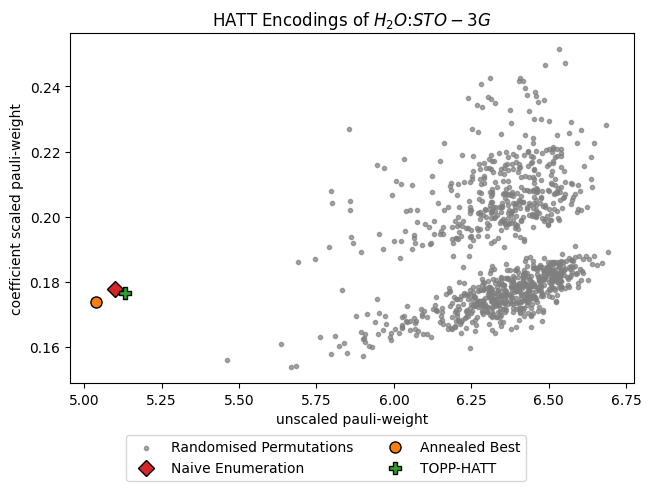

In [ ]:
get_topp_hatt_results(hatt_tree, "HATT")

Getting Naive result...
Getting Annealed result...
Running TOPP-HATT...
Initial Dependencies:
{29: [30], 30: [31, 32], 31: [33, 34], 32: [35, 36], 33: [37, 38], 34: [39, 40], 35: [41, 42], 36: [], 37: [], 38: [], 39: [], 40: [], 41: [], 42: []}
Initial Restrictions:
{29: [[30], None, [28]], 30: [[31], None, [32]], 31: [[33], None, [34]], 32: [[35], None, [36]], 33: [[37], None, [38]], 34: [[39], None, [40]], 35: [[41], None, [42]], 36: [None, None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 37: [None, None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 38: [None, None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 39: [None, None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 40: [None, None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 41: [None, None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 42: [None, None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]]}

Loop 0
active_nodes={36, 37, 38, 39, 40, 41, 42}

parent_index=36


/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_39033/2891475571.py:76: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


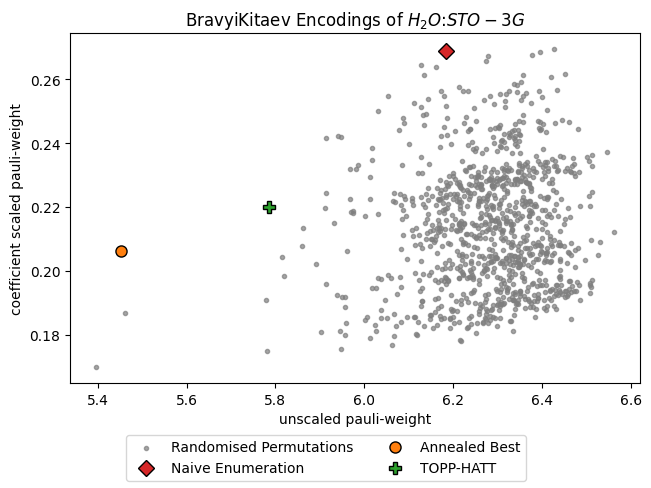

In [ ]:
from ferrmion.encode import BravyiKitaev
get_topp_hatt_results(BravyiKitaev(14), name="BravyiKitaev")

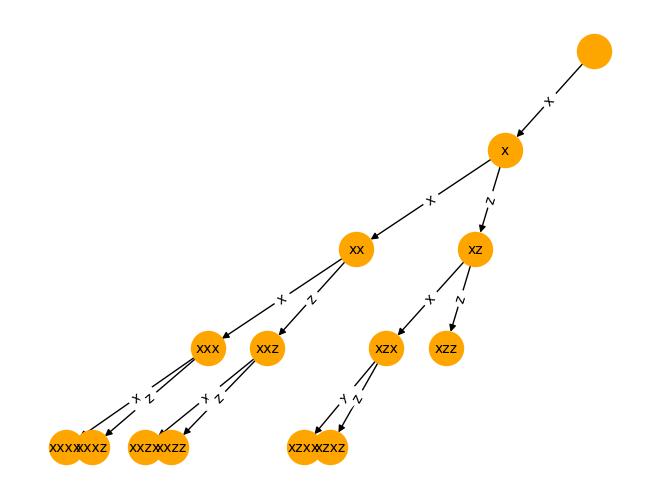

In [ ]:
draw_tt(BravyiKitaev(14))

Getting Naive result...
Getting Annealed result...
Running TOPP-HATT...
Initial Dependencies:
{29: [30], 30: [31], 31: [32], 32: [33], 33: [34], 34: [35], 35: [36], 36: [37], 37: [38], 38: [39], 39: [40], 40: [41], 41: [42], 42: []}
Initial Restrictions:
{29: [[30], None, [28]], 30: [[31], None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 31: [[32], None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 32: [[33], None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 33: [[34], None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 34: [[35], None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 35: [[36], None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 36: [[37], None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 37: [[38], None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 38: [[39], None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 39: [[40], None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 40: [[41],

/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_39033/2891475571.py:76: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


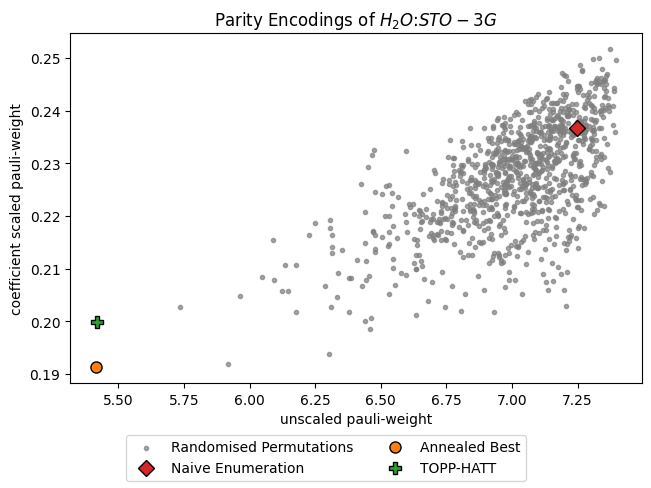

In [ ]:
get_topp_hatt_results(ParityEncoding(14), name="Parity")

Getting Naive result...
Getting Annealed result...
Running TOPP-HATT...
Initial Dependencies:
{29: [30], 30: [31], 31: [32], 32: [33], 33: [34], 34: [35], 35: [36], 36: [37], 37: [38], 38: [39], 39: [40], 40: [41], 41: [42], 42: []}
Initial Restrictions:
{29: [None, None, [30]], 30: [None, None, [31]], 31: [None, None, [32]], 32: [None, None, [33]], 33: [None, None, [34]], 34: [None, None, [35]], 35: [None, None, [36]], 36: [None, None, [37]], 37: [None, None, [38]], 38: [None, None, [39]], 39: [None, None, [40]], 40: [None, None, [41]], 41: [None, None, [42]], 42: [None, None, [28]]}

Loop 0
active_nodes={42}

parent_index=42
parent_restrictions=[None, None, [28]]
parent_index=42, selection=[18, 19, 28]
min_parent=42
restrictor=TTNode (root path:'', Qubit Index:None)
restrictions={29: [None, None, [30]], 30: [None, None, [31]], 31: [None, None, [32]], 32: [None, None, [33]], 33: [None, None, [34]], 34: [None, None, [35]], 35: [None, None, [36]], 36: [None, None, [37]], 37: [None, None

/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_39033/2891475571.py:76: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


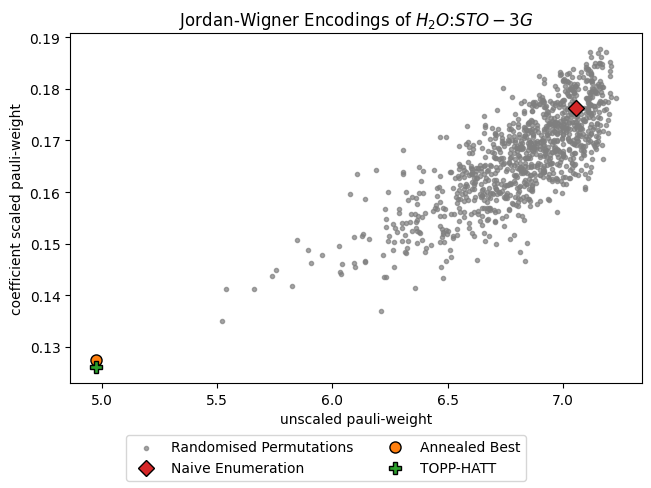

In [ ]:
get_topp_hatt_results(JordanWigner(14), "Jordan-Wigner")

Getting Naive result...
Getting Annealed result...
Running TOPP-HATT...
Initial Dependencies:
{29: [30, 31, 32], 30: [33, 34, 35], 31: [36, 37, 38], 32: [39, 40, 41], 33: [42], 34: [], 35: [], 36: [], 37: [], 38: [], 39: [], 40: [], 41: [], 42: []}
Initial Restrictions:
{29: [[30], [31], [32]], 30: [[33], [34], [35]], 31: [[36], [37], [38]], 32: [[39], [40], [41]], 33: [[42], None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 34: [None, None, [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27]], 35: [None, None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 36: [None, None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 37: [None, None, [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27]], 38: [None, None, [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27]], 39: [None, None, [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]], 40: [None, None, [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27]], 41: [None, None, [28]], 42: [None, None, [0, 2, 4, 6, 8, 10, 12,

/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_39033/2891475571.py:76: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


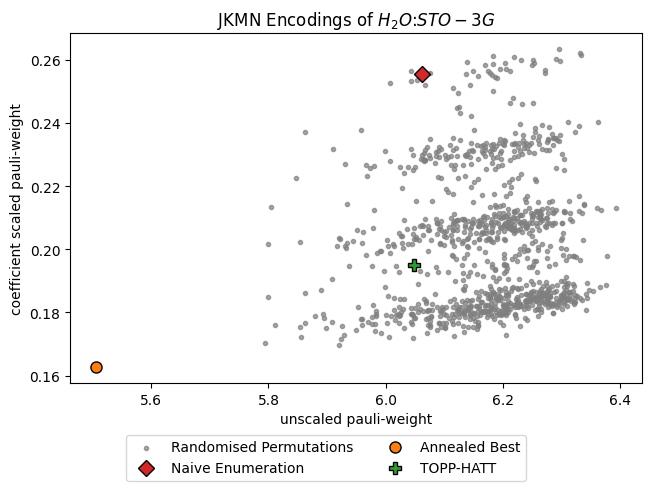

In [ ]:
from ferrmion.encode import JKMN
get_topp_hatt_results(JKMN(14), name="JKMN")

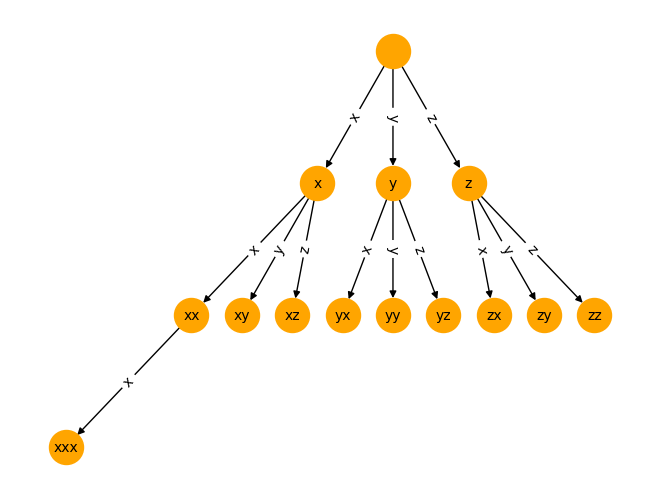

In [ ]:
draw_tt(JKMN(14))